In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from qiskit.primitives import Sampler  # ComputeUncompute usa Sampler, não Estimator

from qiskit_machine_learning.kernels import TrainableFidelityQuantumKernel
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.algorithms import PegasosQSVC
from sklearn.svm import SVC
#import os
#os.environ["OMP_NUM_THREADS"] = "8"
N_QUBITS = 8
df_data = pd.read_csv('features_geometry_70.csv')

X = df_data.drop(columns=['class', 'image_name'])
feature_cols = [
    "dist_thumb_index",
    "dist_index_middle",
    "dist_middle_ring",
    "dist_ring_pinky",
    "angle_index",
    "angle_middle",
    "angle_ring",
    "angle_pinky",
]

X = df_data[feature_cols]

y = df_data['class']

#pca = PCA(n_components=N_QUBITS)
#X_pca= pca.fit_transform(X)  

print(X.shape)
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

#X_final = X_pca.copy()


# 2. Normaliza para [0, π] 
# scaler = MinMaxScaler()
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_scaled = scaler.fit_transform(X)


classes_existentes = sorted(y.unique()) 
n_classes = len(classes_existentes)



X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y , test_size=0.2, random_state=42, stratify=y
)


print("X_train shape:", X_train.shape)  
print("X_test shape: ", X_test.shape)   
print("Primeira amostra:", X_train[0])

(45014, 8)
X_train shape: (36011, 8)
X_test shape:  (9003, 8)
Primeira amostra: [1.34643286 2.62680069 0.334177   0.46221468 0.04786485 2.97054855
 3.07631365 2.86620084]


In [8]:
import json
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit_machine_learning.optimizers import COBYLA, SPSA
from qiskit_machine_learning.utils import algorithm_globals
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier
from qiskit_machine_learning.neural_networks import EstimatorQNN, SamplerQNN
from sklearn.model_selection import train_test_split

algorithm_globals.random_seed = 12345
estimator = Estimator()

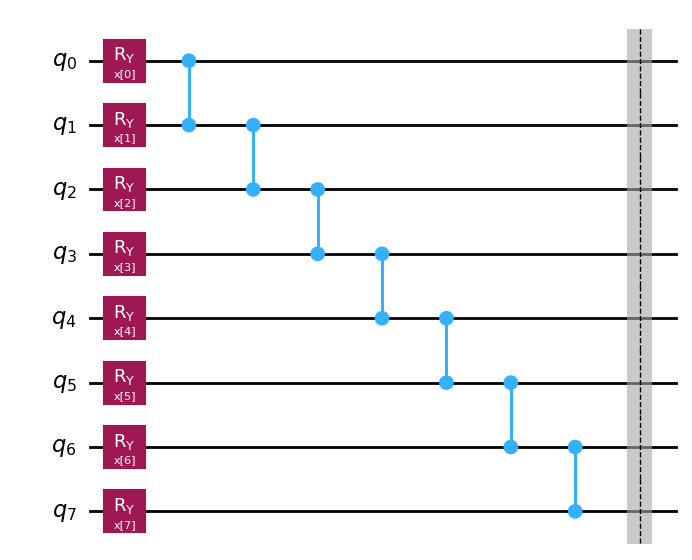

In [19]:
from math import ceil
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

num_features = 8
num_qubits = 8

data_vector = ParameterVector("x", num_features)

def build_data_reupload_only(num_qubits, num_features, data_vector):
    qc = QuantumCircuit(num_qubits)

    num_reuploads = ceil(num_features / num_qubits)
    feature_idx = 0

    for layer in range(num_reuploads):
        for q in range(num_qubits):
            if feature_idx < num_features:
                qc.ry(data_vector[feature_idx], q)
                feature_idx += 1

        for q in range(num_qubits - 1):
            qc.cz(q, q + 1)

        qc.barrier()

    return qc

reupload = build_data_reupload_only(
    num_qubits=num_qubits,
    num_features=num_features,
    data_vector=data_vector
)

reupload.draw("mpl")

Usando 8 qubits


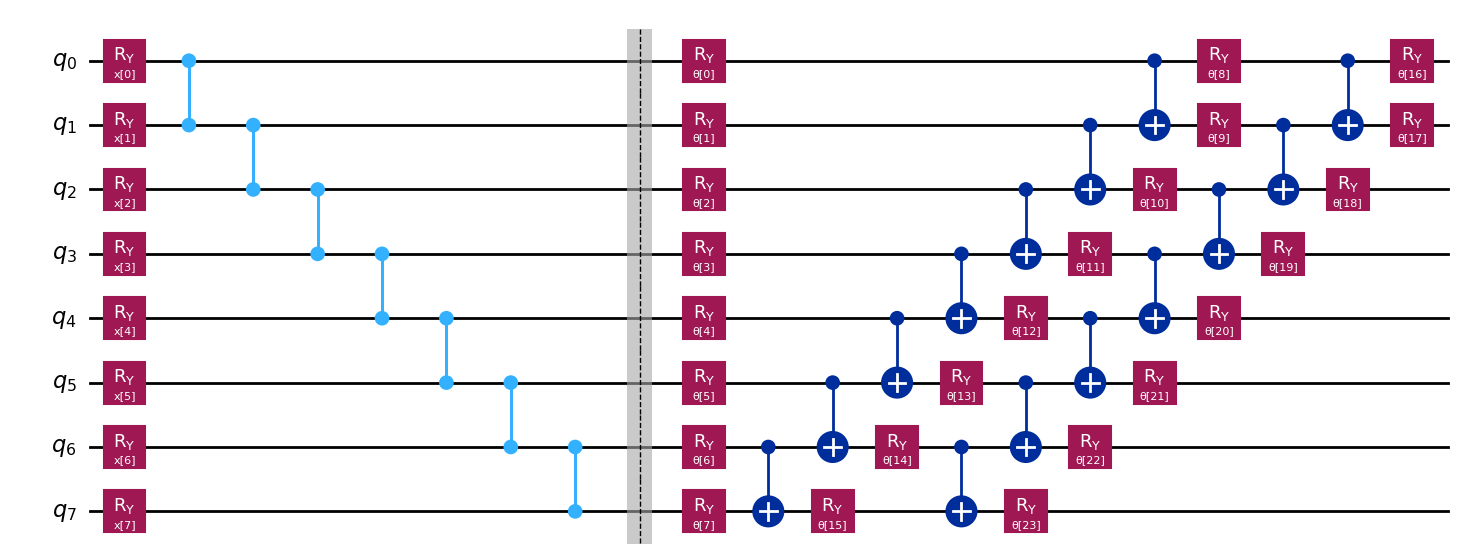

In [20]:
from qiskit.circuit.library import RealAmplitudes
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap
import json
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit_machine_learning.optimizers import COBYLA
from qiskit_machine_learning.utils import algorithm_globals
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier
from qiskit_machine_learning.neural_networks import EstimatorQNN, SamplerQNN
from sklearn.model_selection import train_test_split


num_features = 8       
print(f"Usando {num_features} qubits")



ansatz =  RealAmplitudes(num_features, reps=2) 


qc = QuantumCircuit(num_features)
qc.compose(reupload, inplace=True)
qc.compose(ansatz.decompose(), inplace=True)


qc.draw("mpl", fold=-1)

In [21]:
sampler = Sampler() # Instancia um Sampler padrão se não for fornecido
        
# ComputeUncompute calcula a fidelidade |<ψ(x1)|ψ(x2)>|² usando Sampler
fidelity = ComputeUncompute(sampler=sampler)

# Definimos o Kernel treinável passando quais parâmetros pertencem ao Ansatz
kernel = TrainableFidelityQuantumKernel(
    feature_map=qc,
    fidelity=fidelity,
    training_parameters=ansatz.parameters
)

C:\Users\Milleny\AppData\Local\Temp\ipykernel_35004\1980901076.py:1: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler = Sampler() # Instancia um Sampler padrão se não for fornecido
C:\Users\Milleny\AppData\Local\Temp\ipykernel_35004\1980901076.py:4: DeprecationWarning: V1 Primitives are deprecated as of qiskit-machine-learning 0.8.0 and will be removed no sooner than 4 months after the release date. Use V2 primitives for continued compatibility and support.
  fidelity = ComputeUncompute(sampler=sampler)


In [ ]:
from qiskit.primitives import StatevectorSampler

from qiskit_machine_learning.kernels.algorithms import QuantumKernelTrainer

from qiskit_machine_learning.gradients import SPSAEstimatorGradient
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,f1_score
import seaborn as sns
import matplotlib.pyplot as plt 
optimizer = SPSA(maxiter=100)

# Tratamento caso y_train esteja em One-Hot Encoding (comum no seu notebook)
if len(y_train.shape) > 1 and y_train.shape[1] > 1:
    y_train_labels = np.argmax(y_train, axis=1)
else:
    y_train_labels = y_train


optimizer = COBYLA(maxiter=100, disp=True)

initial_point = np.random.random(kernel.num_training_parameters)

qka_trainer = QuantumKernelTrainer(
    quantum_kernel=kernel,
    loss="svc_loss",
    optimizer=optimizer,
    initial_point=initial_point,
)


result = qka_trainer.fit(X_train, y_train_labels)




trained_kernel = result.quantum_kernel

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from qiskit_machine_learning.algorithms.classifiers import QSVC

qsvc = QSVC(quantum_kernel=trained_kernel)

qsvc.fit(X_train, y_train)

if len(y_train.shape) > 1 and y_train.shape[1] > 1:
    y_train_labels = np.argmax(y_train, axis=1)
    y_test_labels = np.argmax(y_test, axis=1)
else:
    y_train_labels = y_train
    y_test_labels = y_test
y_pred = qsvc.predict(X_test)
acc = accuracy_score(y_test_labels , y_pred)

accuracy_score(y_test_labels, y_pred)
f1_score(y_test_labels, y_pred, average="macro")
confusion_matrix(y_test_labels, y_pred)

Iter   1 → loss = 4.574392


KeyboardInterrupt: 


ACURÁCIA FINAL = 77.59%

Classification Report:
              precision    recall  f1-score   support

           A       0.87      0.65      0.74       213
           B       0.72      0.91      0.80       211

    accuracy                           0.78       424
   macro avg       0.80      0.78      0.77       424
weighted avg       0.80      0.78      0.77       424



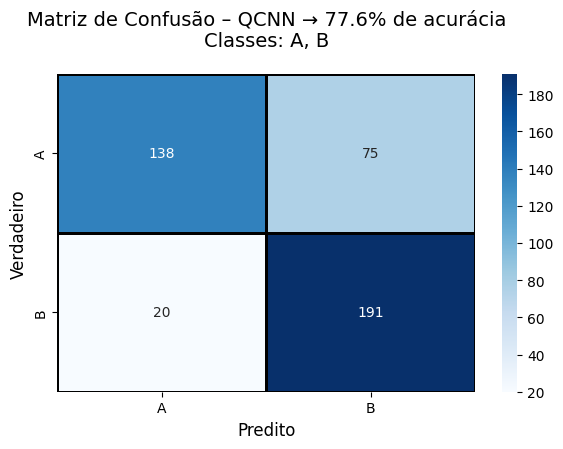

In [ ]:
# =============================================
# AVALIAÇÃO FINAL – CORRIGIDA PARA 2 OU 3 CLASSES
# =============================================
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Converte one-hot → inteiro (0, 1, 2...)
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(classifier.predict(X_test), axis=1)

acc = accuracy_score(y_true, y_pred)

print(f"\nACURÁCIA FINAL = {acc*100:.2f}%\n")

# Classification Report com os nomes corretos (só as letras que você escolheu!)
print("Classification Report:")
print(classification_report(y_true, y_pred, 
                          target_names=classes_existentes))  # ← usa a lista real: ['A', 'B'] ou ['A', 'B', 'C']


